In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [3]:
# Load the dataset
df_gdg_by_sector_by_country = pd.read_excel("sample_data/EDGAR_2025_GHG_booklet_2025.xlsx", sheet_name='GHG_by_sector_and_country')
df_gdg_by_sector_by_country.head()

,Substance,Sector,EDGAR Country Code,Country,1970,1971,1972,1973,1974,1975,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,CO2,Agriculture,AFG,Afghanistan,0.029229,0.029229,0.029229,0.029229,0.039967,0.045310,...,0.116967,0.163009,0.311300,0.161333,0.151276,0.064795,0.040490,0.053114,0.052360,0.051832
1,CO2,Agriculture,ALB,Albania,0.113300,0.113300,0.113300,0.113300,0.113614,0.112514,...,0.056519,0.047405,0.054162,0.046462,0.066419,0.060552,0.048348,0.060657,0.061956,0.063322
2,CO2,Agriculture,ARG,Argentina,0.104343,0.104343,0.104343,0.104343,0.087214,0.077314,...,0.892257,1.385790,1.278409,1.592119,1.703062,1.925471,2.071404,1.941500,2.038488,2.154144
3,CO2,Agriculture,ARM,Armenia,0.055288,0.055288,0.055288,0.055288,0.059966,0.059966,...,0.033943,0.039443,0.052486,0.051071,0.061024,0.055838,0.044629,0.041800,0.041989,0.042187
4,CO2,Agriculture,AUS,Australia,0.311143,0.311143,0.311143,0.311143,0.311143,0.268190,...,2.324928,2.542624,2.949833,2.130700,2.275585,2.664304,3.253852,2.862671,2.810286,2.791744


In [6]:
# Reshape the data (Pivot from wide to long)
melted_df = df_gdg_by_sector_by_country.melt(id_vars=['Country', 'Substance', 'Sector'],
                            value_vars=[year for year in range(1970, 2025)],
                            var_name='Year', value_name='GHG_Total')

# Ensure Year is numeric for the x-axis
melted_df['Year'] = melted_df['Year'].astype(int)
melted_df.head()

,Country,Substance,Sector,Year,GHG_Total
0,Afghanistan,CO2,Agriculture,1970,0.029229
1,Albania,CO2,Agriculture,1970,0.113300
2,Argentina,CO2,Agriculture,1970,0.104343
3,Armenia,CO2,Agriculture,1970,0.055288
4,Australia,CO2,Agriculture,1970,0.311143


In [14]:
# Filter top 10 countries by GHG emissions
df_top_10_sectors_by_ghg = duckdb.query("""
                              SELECT Sector, SUM(GHG_Total) AS GHG_Total
                              FROM melted_df
                              WHERE Country NOT IN ('GLOBAL TOTAL', 'EU27')
                              GROUP BY Sector
                              ORDER BY GHG_Total
                              DESC LIMIT 10
                              """).to_df()
df_top_10_sectors_by_ghg

,Sector,GHG_Total
0,Power Industry,514348.587467
1,Transport,307790.857896
2,Agriculture,280023.564013
3,Industrial Combustion,258244.473378
4,Fuel Exploitation,241672.131077
5,Buildings,196169.467671
6,Processes,153195.229571
7,Waste,74794.238452


In [16]:
# Select specific countries and extract list
sectors_to_plot = df_top_10_sectors_by_ghg['Sector'].to_list()
sectors_to_plot

['Power Industry',
 'Transport',
 'Agriculture',
 'Industrial Combustion',
 'Fuel Exploitation',
 'Buildings',
 'Processes',
 'Waste']

In [17]:
filtered_df = melted_df[melted_df['Sector'].isin(sectors_to_plot)]

print(df_top_10_sectors_by_ghg.shape)
print(melted_df.shape)
print(filtered_df.shape)

(8, 2)
(266695, 5)
(266585, 5)


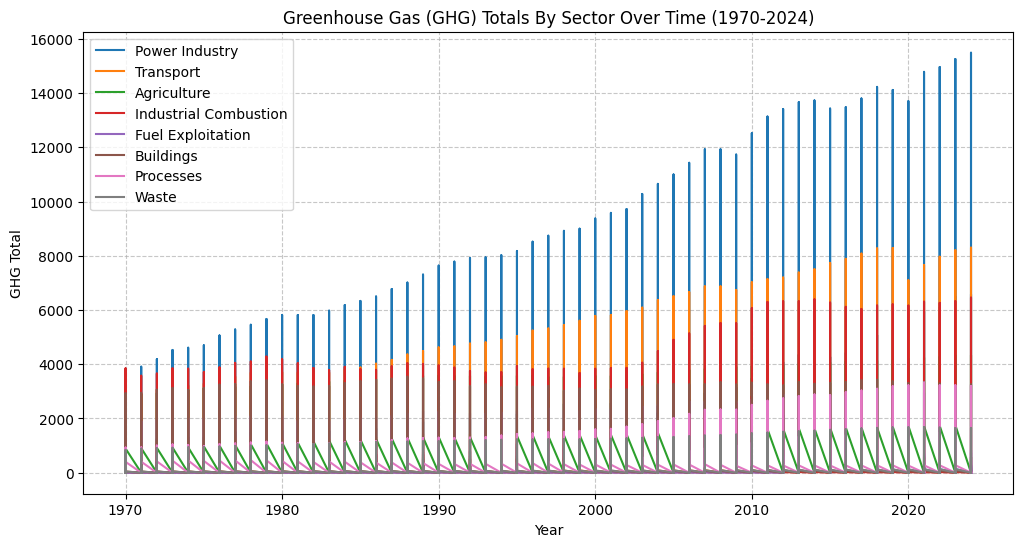

In [18]:
# Create the plot
plt.figure(figsize=(12, 6))

for sector in sectors_to_plot:
    subset = filtered_df[filtered_df['Sector'] == sector]
    plt.plot(subset['Year'], subset['GHG_Total'], label=sector)

# 6. Customize the chart
plt.title('Greenhouse Gas (GHG) Totals By Sector Over Time (1970-2024)')
plt.xlabel('Year')
plt.ylabel('GHG Total')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 7. Display or save the result
plt.savefig('ghg_by_sector_line_chart.png')
plt.show()